In [5]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs visible: {len(gpus)}", ("✅ Using GPU" if gpus else "⚠️ No GPU"))

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping


GPUs visible: 1 ✅ Using GPU


In [6]:
DATASET_PATH = "/kaggle/input/skin-cancer-mnist-ham10000/"
meta_csv = os.path.join(DATASET_PATH, "HAM10000_metadata.csv")
metadata = pd.read_csv(meta_csv)

all_image_dir = [
    os.path.join(DATASET_PATH, "HAM10000_images_part_1"),
    os.path.join(DATASET_PATH, "HAM10000_images_part_2")
]

def get_image_path(image_id):
    for d in all_image_dir:
        path = os.path.join(d, image_id + ".jpg")
        if os.path.exists(path):
            return path
    return None

metadata['image_path'] = metadata['image_id'].apply(get_image_path)
metadata = metadata.dropna(subset=['image_path']).reset_index(drop=True)

# Encode labels
le = LabelEncoder()
metadata['label'] = le.fit_transform(metadata['dx'])
num_classes = metadata['label'].nunique()
class_names = le.classes_

# Train / Val / Test split
train_df, test_df = train_test_split(
    metadata,
    test_size=0.1,
    stratify=metadata['label'],
    random_state=42
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['label'],
    random_state=42
)

print(f"Train size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(test_df)}")

# Dataset pipeline
AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = 224
BATCH_SIZE = 16

from tensorflow.keras.applications.convnext import preprocess_input as convnext_preprocess

def preprocess_image(file_path, label, augment=False):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = convnext_preprocess(img)
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
    return img, label

def make_ds(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((df['image_path'].values, df['label'].values))
    if training:
        ds = ds.shuffle(min(len(df), 2000))
        ds = ds.map(lambda f, y: preprocess_image(f, y, augment=True), num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(lambda f, y: preprocess_image(f, y, augment=False), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(train_df, training=True)
val_ds   = make_ds(val_df, training=False)
test_ds  = make_ds(test_df, training=False)

# Class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Train size: 7210, Val size: 1803, Test size: 1002
Class Weights: {0: 4.382978723404255, 1: 2.7837837837837838, 2: 1.302149178255373, 3: 12.409638554216867, 4: 1.28428927680798, 5: 0.21338305365651544, 6: 10.098039215686274}


I0000 00:00:1757840624.913271      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [7]:
from tensorflow.keras.applications import ConvNeXtLarge

# Base model
base_model = ConvNeXtLarge(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Stage 1 training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weights,
    callbacks=[early_stop]
)

# Fine-tuning (Stage 2)
base_model.trainable = True
for layer in base_model.layers[:-200]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

# Save in Keras V3 format
model.save("/kaggle/working/convnext_large_finetuned.keras")
print("Model saved in .keras format!")

785596384/785596384 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/50


I0000 00:00:1757840659.620094     101 service.cc:148] XLA service 0x79b4340170b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757840659.620729     101 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1757840662.877650     101 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1757840668.991772     101 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


451/451 ━━━━━━━━━━━━━━━━━━━━ 149s 257ms/step - accuracy: 0.4518 - loss: 1.8455 - val_accuracy: 0.6550 - val_loss: 0.9298
Epoch 2/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 99s 219ms/step - accuracy: 0.6086 - loss: 1.0654 - val_accuracy: 0.6622 - val_loss: 0.8630
Epoch 3/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 98s 218ms/step - accuracy: 0.6652 - loss: 0.8504 - val_accuracy: 0.7271 - val_loss: 0.7473
Epoch 4/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 98s 217ms/step - accuracy: 0.6937 - loss: 0.7692 - val_accuracy: 0.7216 - val_loss: 0.7566
Epoch 5/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 98s 217ms/step - accuracy: 0.7239 - loss: 0.6707 - val_accuracy: 0.7432 - val_loss: 0.6969
Epoch 6/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 97s 215ms/step - accuracy: 0.7171 - loss: 0.6754 - val_accuracy: 0.7099 - val_loss: 0.7960
Epoch 7/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 97s 215ms/step - accuracy: 0.6992 - loss: 0.6720 - val_accuracy: 0.7404 - val_loss: 0.6432
Epoch 8/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 97s 215ms/step - accuracy: 0.7445 - loss: 0.6292 - va

E0000 00:00:1757842524.724606     102 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757842524.926840     102 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757842525.254305     102 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757842525.491710     102 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


450/451 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.7596 - loss: 0.5582

E0000 00:00:1757842867.372792     101 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757842867.574800     101 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757842867.901620     101 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757842868.138332     101 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


451/451 ━━━━━━━━━━━━━━━━━━━━ 472s 839ms/step - accuracy: 0.7597 - loss: 0.5580 - val_accuracy: 0.7743 - val_loss: 0.6060
Epoch 2/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 334s 741ms/step - accuracy: 0.8111 - loss: 0.3994 - val_accuracy: 0.8109 - val_loss: 0.4869
Epoch 3/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 334s 740ms/step - accuracy: 0.8540 - loss: 0.2566 - val_accuracy: 0.8148 - val_loss: 0.5111
Epoch 4/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 333s 739ms/step - accuracy: 0.8839 - loss: 0.1839 - val_accuracy: 0.8125 - val_loss: 0.5021
Epoch 5/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 334s 740ms/step - accuracy: 0.9021 - loss: 0.1276 - val_accuracy: 0.8286 - val_loss: 0.4702
Epoch 6/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 334s 741ms/step - accuracy: 0.9185 - loss: 0.0995 - val_accuracy: 0.8674 - val_loss: 0.3837
Epoch 7/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 334s 740ms/step - accuracy: 0.9430 - loss: 0.0809 - val_accuracy: 0.8747 - val_loss: 0.3680
Epoch 8/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 333s 739ms/step - accuracy: 0.9491 - loss: 0.06

In [8]:
import os
print(os.listdir("/kaggle/working/"))


['.virtual_documents', 'convnext_large_finetuned.keras']


In [9]:
from tensorflow.keras.models import load_model

model = load_model("/kaggle/working/convnext_large_finetuned.keras")
print("Model loaded successfully!")


Model loaded successfully!


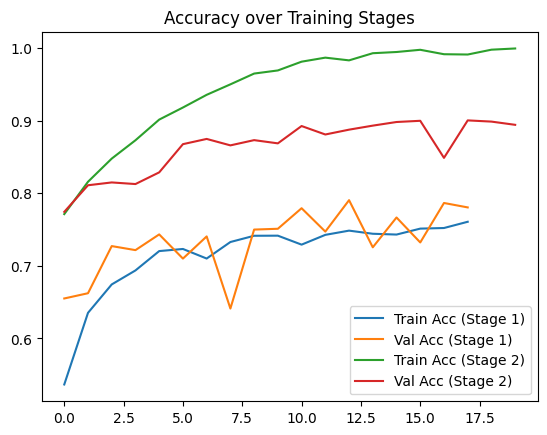

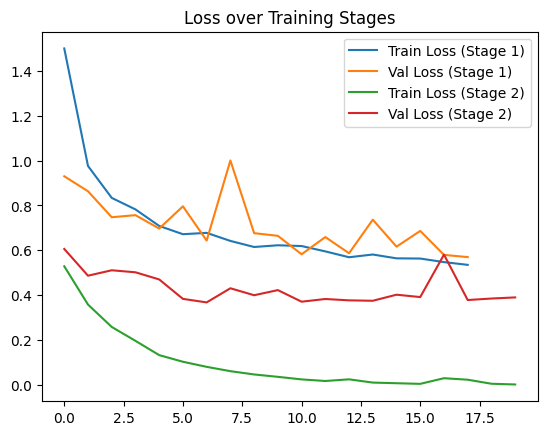

113/113 ━━━━━━━━━━━━━━━━━━━━ 34s 238ms/step

Validation Classification Report:

              precision    recall  f1-score   support

       akiec       0.72      0.64      0.68        59
         bcc       0.78      0.83      0.80        93
         bkl       0.81      0.84      0.83       198
          df       0.91      0.50      0.65        20
         mel       0.79      0.72      0.76       200
          nv       0.95      0.96      0.96      1207
        vasc       0.89      0.96      0.93        26

    accuracy                           0.90      1803
   macro avg       0.84      0.78      0.80      1803
weighted avg       0.90      0.90      0.90      1803



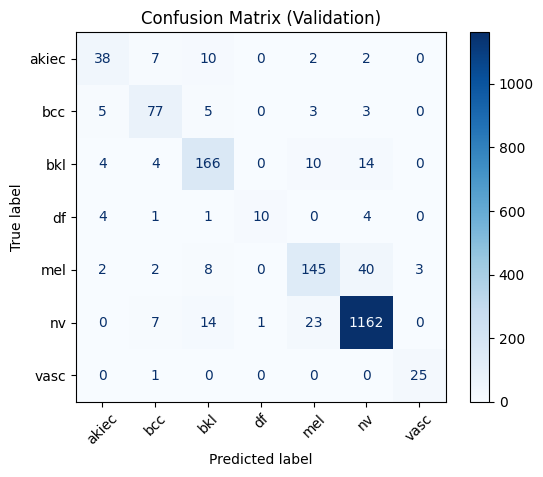

63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 210ms/step

Test Classification Report:

              precision    recall  f1-score   support

       akiec       0.71      0.82      0.76        33
         bcc       0.75      0.80      0.77        51
         bkl       0.77      0.81      0.79       110
          df       0.70      0.58      0.64        12
         mel       0.76      0.68      0.72       111
          nv       0.95      0.95      0.95       671
        vasc       0.93      0.93      0.93        14

    accuracy                           0.89      1002
   macro avg       0.80      0.80      0.79      1002
weighted avg       0.89      0.89      0.89      1002



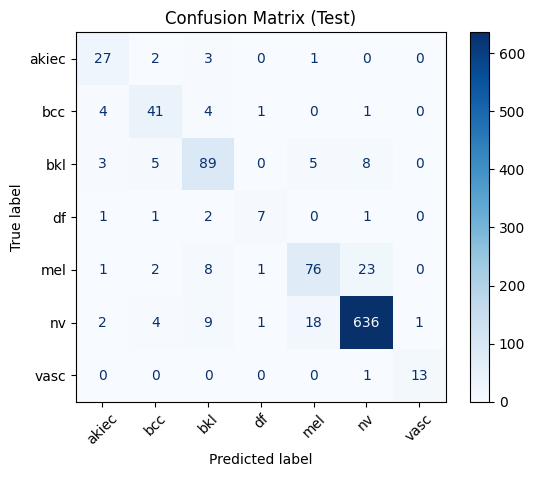

In [10]:
# Training curves
plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc (Stage 1)')
plt.plot(history.history['val_accuracy'], label='Val Acc (Stage 1)')
plt.plot(fine_tune_history.history['accuracy'], label='Train Acc (Stage 2)')
plt.plot(fine_tune_history.history['val_accuracy'], label='Val Acc (Stage 2)')
plt.legend(); plt.title("Accuracy over Training Stages")
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss (Stage 1)')
plt.plot(history.history['val_loss'], label='Val Loss (Stage 1)')
plt.plot(fine_tune_history.history['loss'], label='Train Loss (Stage 2)')
plt.plot(fine_tune_history.history['val_loss'], label='Val Loss (Stage 2)')
plt.legend(); plt.title("Loss over Training Stages")
plt.show()

# Validation report
y_val_true = val_df['label'].values
y_val_pred = model.predict(val_ds).argmax(axis=1)

print("\nValidation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred, target_names=class_names))

cm = confusion_matrix(y_val_true, y_val_pred, labels=range(num_classes))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
    xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix (Validation)")
plt.show()

# Test report
y_test_true = test_df['label'].values
y_test_pred = model.predict(test_ds).argmax(axis=1)

print("\nTest Classification Report:\n")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))

cm = confusion_matrix(y_test_true, y_test_pred, labels=range(num_classes))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
    xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix (Test)")
plt.show()


In [11]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_and_show_images(model, le, img_paths, target_size=(224, 224)):
    """
    Show predictions for given image paths with class and confidence only.
    """
    idx_to_class = {i: label for i, label in enumerate(le.classes_)}
    
    plt.figure(figsize=(5*len(img_paths), 5))
    
    for i, img_path in enumerate(img_paths):
        # Load image
        img = image.load_img(img_path, target_size=target_size)
        img_array = np.expand_dims(image.img_to_array(img), axis=0)
        img_array = convnext_preprocess(img_array)

        # Predict
        preds = model.predict(img_array, verbose=0)
        pred_idx = np.argmax(preds, axis=1)[0]
        pred_class = idx_to_class[pred_idx]
        confidence = np.max(preds)

        # Plot
        plt.subplot(1, len(img_paths), i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Pred: {pred_class}\nConf: {confidence:.2f}", fontsize=10)

    plt.tight_layout()
    plt.show()


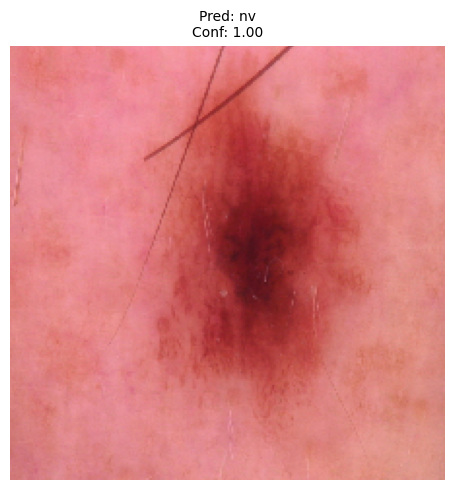

In [14]:
# List of your chosen image paths
sample_images = [
    "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024306.jpg" ]

predict_and_show_images(model, le, sample_images)
